## Project

## Exploring global literacy rates by age and gender using World Bank data

## How to use this notebook

The project can be read by just opening this notebook, but if you wish to run it yourself follow these steps:

1. Open `project.ipynb` in Jupyter Notebook
3. Run all cells from top to bottom
4. Results and raw data will be exported to the `exports/` folder

No API key or account is needed. The World Bank API is free and public

## Data Pipeline

![Data Pipeline](pipeline.png)

## Introduction

This project analyzes global literacy rates across three age groups Youth (15–24 years), Adults (25–64 years) and Elderly (65+ years) to determine how literacy rates differ by age group and gender. Global regions are also included in the analysis to show regional differences. 

The goal is to answer: **What are the current differences in literacy rates globally based on gender, age group and global regions?**

The original idea explored in assignment 2, was to analyze how literacy rates have developed during the recent decades around the world. However, the Kaggle data didn't fully support this analysis since the data didn't include enough country values for the same years. Therefore, data is fetched directly from the World Bank API, which provides the most recent available literacy data per country.

Data source: World Bank Education Statistics database

## Loading the data with the API

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests

In [2]:
# Gets the data from World Bank and filter to only collect real countries and not regions 
# The API is public and therefore not hidden on purpose as we only use the url
r = requests.get("https://api.worldbank.org/v2/country?format=json&per_page=300", timeout=30)
country_records = r.json()[1]

real_countries = {
    c["id"]: {"Country Name": c["name"], "Region": c["region"]["value"]}
    for c in country_records
    if c["region"]["value"] not in ("", "Aggregates")
}

print(f"Countries loaded: {len(real_countries)}")

Countries loaded: 217


## Filtering and cleaning data

In [3]:
# Creates shorter names for the World Bank indicators to use for charts
INDICATORS = {
    "Youth (both)":    "SE.ADT.1524.LT.ZS",
    "Youth (male)":    "SE.ADT.1524.LT.MA.ZS",
    "Youth (female)":  "SE.ADT.1524.LT.FE.ZS",
    "Adult (both)":    "UIS.LR.AG25T64",
    "Adult (male)":    "UIS.LR.AG25T64.M",
    "Adult (female)":  "UIS.LR.AG25T64.F",
    "Elderly (both)":  "UIS.LR.AG65",
    "Elderly (male)":  "UIS.LR.AG65.M",
    "Elderly (female)":"UIS.LR.AG65.F",
}

In [4]:
rows = []

for label, code in INDICATORS.items():
    print(f"Fetching {label}...")
    page, results = 1, []

    # Gets all pages of data for this indicator from the API
    while True:
        url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?format=json&per_page=5000&page={page}"
        payload = requests.get(url, timeout=30).json()
        if len(payload) < 2 or not payload[1]:
            break
        results.extend(payload[1])
        if page >= payload[0]["pages"]:
            break
        page += 1

    # Keeps only the most recent non-null value per country
    best = {}
    for rec in results:
        cc = rec["countryiso3code"] or rec["country"]["id"]
        if cc not in real_countries or rec["value"] is None:
            continue
        year, val = str(rec["date"]), float(rec["value"])
        if cc not in best or year > best[cc][1]:
            best[cc] = (val, year)

    # Adds the best value for each country to the rows list
    for cc, (val, year) in best.items():
        rows.append({
            "Country Code": cc,
            "Country Name": real_countries[cc]["Country Name"],
            "Region":       real_countries[cc]["Region"],
            "Age Group":    label,
            "Literacy Rate": val,
            "Year":         year,
        })

df = pd.DataFrame(rows)
print(f"\nDone. {len(df)} rows, {df['Country Name'].nunique()} countries.")
display(df.head(10))

Fetching Youth (both)...
Fetching Youth (male)...
Fetching Youth (female)...
Fetching Adult (both)...
Fetching Adult (male)...
Fetching Adult (female)...
Fetching Elderly (both)...
Fetching Elderly (male)...
Fetching Elderly (female)...

Done. 1508 rows, 174 countries.


,Country Code,Country Name,Region,Age Group,Literacy Rate,Year
0,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Youth (both),62.660000,2022
1,ALB,Albania,Europe & Central Asia,Youth (both),99.059998,2023
2,DZA,Algeria,"Middle East, North Africa, Afghanistan & Pakistan",Youth (both),93.769997,2008
3,ASM,American Samoa,East Asia & Pacific,Youth (both),97.650002,1980
4,AGO,Angola,Sub-Saharan Africa,Youth (both),80.699997,2023
5,ARG,Argentina,Latin America & Caribbean,Youth (both),99.680000,2020
6,ARM,Armenia,Europe & Central Asia,Youth (both),99.889999,2023
7,ABW,Aruba,Latin America & Caribbean,Youth (both),99.139999,2010
8,AZE,Azerbaijan,Europe & Central Asia,Youth (both),99.879997,2023
9,BHR,Bahrain,"Middle East, North Africa, Afghanistan & Pakistan",Youth (both),99.519997,2024


## Exports feched raw data

In [5]:
# Exports the raw data fetched from the API
os.makedirs("exports", exist_ok=True)
df.to_csv("exports/literacy_raw.csv", index=False)
print("Raw data saved to exports/literacy_raw.csv")

Raw data saved to exports/literacy_raw.csv


## Summary statistics

In [6]:
# Summary statistics by age group
summary = df.groupby("Age Group")["Literacy Rate"].describe()
display(summary)

,count,mean,std,min,25%,50%,75%,max
Age Group,,,,,,,,
Adult (both),164.0,82.806231,21.907384,1.704710,73.694172,94.271975,98.921520,99.99998
Adult (female),164.0,79.427519,26.149348,0.407880,67.107690,93.571895,98.847777,99.99998
Adult (male),164.0,86.338312,17.930001,3.052130,80.104763,94.773425,99.109727,99.99998
Elderly (both),166.0,65.932758,29.668582,4.576800,39.139678,73.682685,93.797965,99.98765
Elderly (female),166.0,59.406911,34.314721,0.717830,24.506428,66.346170,92.978580,99.98556
Elderly (male),166.0,73.577710,25.724244,9.714170,53.176390,84.546710,96.341933,100.00000
Youth (both),172.0,91.901457,12.502706,36.700001,90.382500,98.189999,99.610001,100.00000
Youth (female),173.0,91.386321,14.796029,24.870000,91.300003,98.617895,99.669998,100.00000
Youth (male),173.0,93.265404,10.077947,44.080002,90.790001,98.190002,99.639999,100.00000


## Visualizations

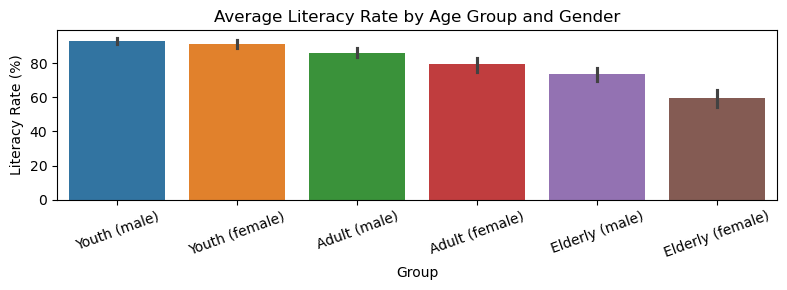

In [7]:
# Compares male vs female literacy across the three age groups
gender = df[~df["Age Group"].str.contains("both")]

plt.figure(figsize=(8, 3))
sns.barplot(data=gender, x="Age Group", y="Literacy Rate", hue="Age Group",
            order=["Youth (male)", "Youth (female)", 
                   "Adult (male)", "Adult (female)",
                   "Elderly (male)", "Elderly (female)"]),
plt.title("Average Literacy Rate by Age Group and Gender")
plt.xlabel("Group")
plt.ylabel("Literacy Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

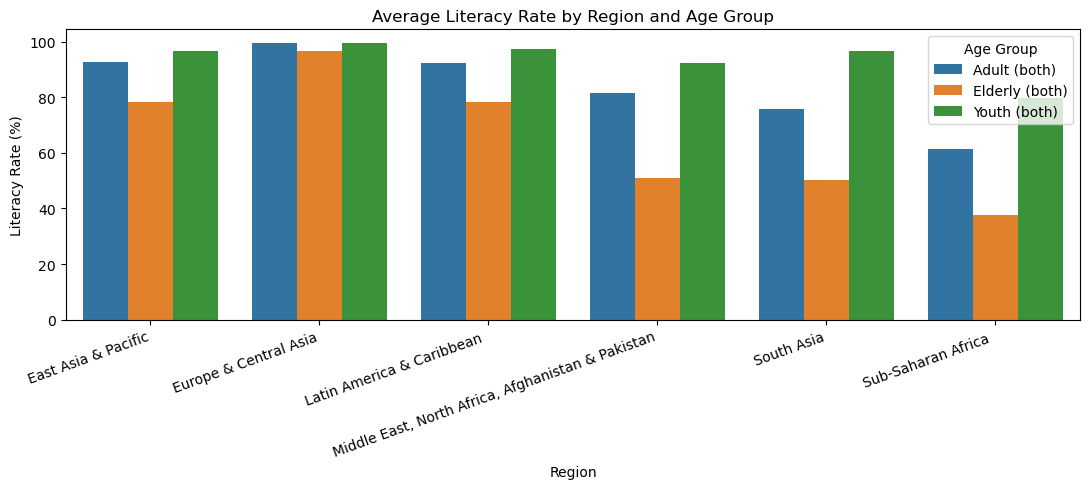

In [8]:
both_sexes = df[df["Age Group"].str.contains("both")]

# Average literacy by region for each age group for both sexes
region_literacy = both_sexes.groupby(["Region", "Age Group"])["Literacy Rate"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.barplot(data=region_literacy, x="Region", y="Literacy Rate", hue="Age Group")
plt.title("Average Literacy Rate by Region and Age Group")
plt.xlabel("Region")
plt.ylabel("Literacy Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

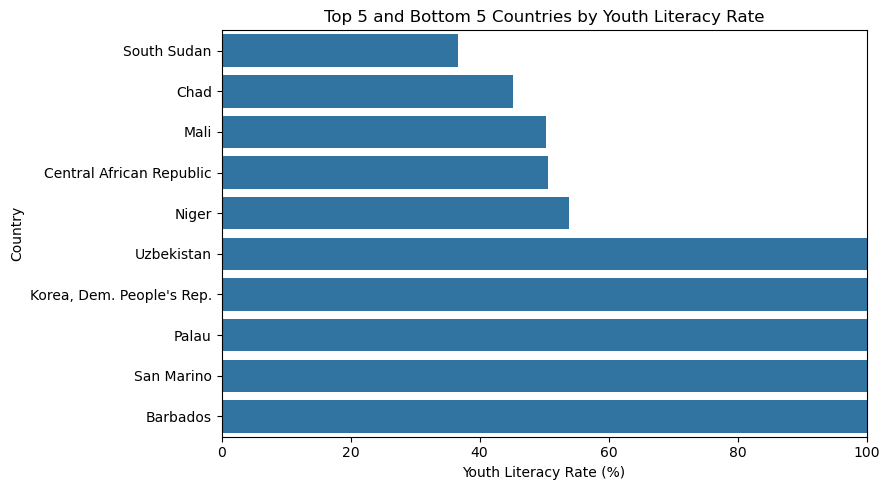

In [9]:
# Bottom 5 and top 5 countries by youth literacy rate
youth_both = df[df["Age Group"] == "Youth (both)"].sort_values("Literacy Rate")

bottom5 = youth_both.head(5)
top5 = youth_both.tail(5)
top_bottom = pd.concat([bottom5, top5])

plt.figure(figsize=(9, 5))
sns.barplot(data=top_bottom, x="Literacy Rate", y="Country Name")
plt.title("Top 5 and Bottom 5 Countries by Youth Literacy Rate")
plt.xlabel("Youth Literacy Rate (%)")
plt.ylabel("Country")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

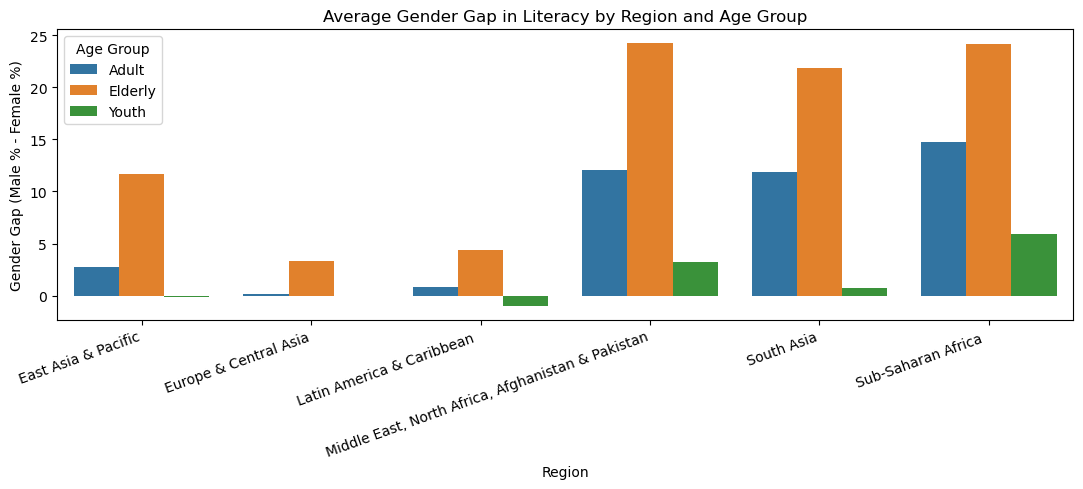

In [10]:
# Calculates the gender gap (male minus female) per country and age group
male = df[df["Age Group"].str.contains("male") & ~df["Age Group"].str.contains("female")]
female = df[df["Age Group"].str.contains("female")]

# Merges male and female on country and age group category
male = male.copy()
female = female.copy()
male["Group"] = male["Age Group"].str.extract(r"(\w+) \(male\)")
female["Group"] = female["Age Group"].str.extract(r"(\w+) \(female\)")

gap = male.merge(female, on=["Country Name", "Country Code", "Region", "Group"],
                 suffixes=("_male", "_female"))
gap["Gender Gap"] = gap["Literacy Rate_male"] - gap["Literacy Rate_female"]

# Average gender gap by region and age group
gap_summary = gap.groupby(["Region", "Group"])["Gender Gap"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.barplot(data=gap_summary, x="Region", y="Gender Gap", hue="Group")
plt.title("Average Gender Gap in Literacy by Region and Age Group")
plt.xlabel("Region")
plt.ylabel("Gender Gap (Male % - Female %)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

In [11]:
# Exports the final dataset
df.to_csv("exports/literacy_results.csv", index=False)
print("Results saved to exports/literacy_results.csv")

# Exports regional summary
region_literacy.to_csv("exports/literacy_by_region.csv", index=False)
print("Regional summary saved to exports/literacy_by_region.csv")

Results saved to exports/literacy_results.csv
Regional summary saved to exports/literacy_by_region.csv


## Conclusions and findings

  Based on the analysis, we can see that there are large differences between literacy geographically and based on age groups and gender, and that improvement has happended globally.

  Youth has the highest literacy rates globally, then adults and lastly elderly. This proves that there has been significant improvement in literacy. The gender gap also decreases from elderly to youth group showing that access to education has become more equal for women.

  The improvement in literacy rates has been highest in Africa and South Asia, and lower in Europe and Central Asia where the rates were quite high for elderly already. 

 The top 5 countries all show 100% youth literacy rates. These are likely small countries where data collection methods might differ 
from larger countries.

## Statement of AI use

Claude was used to help with some of the technical parts of the project like exporting and importing the data correctly so that others can use this notebook without Kaggle or their own API. The idea for this project, data source and what was analyzed was chosen by myself and AI was not used to plan/execute the project.